In [1]:
import pandas as pd
import os 
from collections import Counter

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional
from scipy import stats

def plot_bipo_data(
    data_bipo: Dict[str, Dict[str, Dict[str, Dict[float, float]]]], 
    subplot_titles: Optional[Dict[str, str]] = None,
    main_title: str = "Power-Seeking Evaluation Results"
):
    # 1. Paper-Ready Style
    plt.rcParams.update({
        'font.family': 'serif', 'font.size': 11, 'axes.linewidth': 1.2,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'grid.alpha': 0.3
    })

    unique_names = sorted({n for g in data_bipo.values() for n in g})
    num_instances = len(unique_names)
    
    # --- DYNAMIC COLOR PALETTE LOGIC ---
    # Automatically scale the colormap based on how many unique names exist
    if num_instances <= 10:
        cmap = plt.get_cmap('tab10')
        color_list = [cmap(i) for i in range(num_instances)]
    elif num_instances <= 20:
        cmap = plt.get_cmap('tab20')
        color_list = [cmap(i) for i in range(num_instances)]
    else:
        # If > 20 instances, sample evenly across a vibrant continuous colormap
        cmap = plt.get_cmap('turbo') # 'hsv' is also a good alternative here
        color_list = [cmap(i / num_instances) for i in range(num_instances)]
        
    colors = {n: color_list[i] for i, n in enumerate(unique_names)}

    fig, axes = plt.subplots(5, len(data_bipo), figsize=(5.5 * len(data_bipo), 22), squeeze=False)

    for col, (comp_name, data_group) in enumerate(data_bipo.items()):
        if subplot_titles and comp_name in subplot_titles:
            axes[0, col].set_title(subplot_titles[comp_name], pad=20, fontweight='bold')

        steer_data, steer_consist_data, avg_util_data = [], [], []

        for name, metrics in data_group.items():
            clr = colors[name]
            
            # --- LINE PLOTS (Row 0 for Behavior, Row 3 for Utility) ---
            for row, m_key in [(0, "behavior"), (3, "utility")]:
                if m_key in metrics:
                    x_sorted = sorted(metrics[m_key].keys())
                    y_sorted = [metrics[m_key][k] for k in x_sorted]
                    
                    y_zero = None
                    y_sorted_no_zero = y_sorted.copy()
                    if 0 in x_sorted:
                        zero_index = x_sorted.index(0)      
                        y_zero = y_sorted[zero_index]
                        y_sorted_no_zero.pop(zero_index)

                    marker = "s" if m_key == "behavior" else "^"
                    
                    axes[row, col].plot(x_sorted, y_sorted, marker=marker, color=clr, label=name, mec='black', mew=0.8, lw=2.5)
                    
                    # Compute bar chart metrics
                    if m_key == "behavior" and len(x_sorted) > 1:
                        index = np.arange(len(y_sorted))
                        # Steerability (Row 1)
                        steer_data.append((name, np.polyfit(x_sorted, y_sorted, 1)[0]))
                        # Steering Consistency using Kendall Tau (Row 2)
                        tau, _ = stats.kendalltau(index, y_sorted)
                        # Handle potential NaNs if data has no variance
                        if np.isnan(tau): tau = 0.0 
                        steer_consist_data.append((name, tau))
                        
                    if m_key == "utility" and y_sorted:
                        if y_zero is not None and len(y_sorted_no_zero) > 0:
                            avg_util_data.append((name, np.mean([y-y_zero for y in y_sorted_no_zero])))

        # --- ROW-SPECIFIC FORMATTING ---
        row_labels = ["Behavior Score", "Steerability", "Steering Consistency", "Utility Score", "Utility Consistency"]
        row_sources = [None, steer_data, steer_consist_data, None, avg_util_data]

        for row in range(5):
            ax = axes[row, col]
            source = row_sources[row]

            if source is not None: # Bar Charts
                source.sort(key=lambda i: i[1], reverse=True)
                for name, val in source:
                    # Clipping limits based on the metric
                    limit = 1.0 if row == 2 else (1.5 if row == 1 else 5.0)
                    display_val = np.clip(val, -limit, limit)
                    
                    bar = ax.bar(name, display_val, color=colors[name], edgecolor='black', alpha=0.9, linewidth=1.2)
                    
                    va = 'bottom' if val >= 0 else 'top'
                    offset = 0.08 if row == 2 else (0.05 if row == 4 else 0.02)
                    text_y = display_val + (offset if val >= 0 else -offset)
                    
                    ax.text(bar[0].get_x() + bar[0].get_width()/2, text_y, 
                            f'{val:.2f}', ha='center', va=va, fontsize=9, fontweight='bold')
                
                ax.set_xticks([])
                ax.axhline(0, color='black', linewidth=1.0, alpha=0.5) 
            else: # Line Charts
                ax.legend(loc='upper left', fontsize=8, framealpha=0.5)
                ax.set_xlabel('Multiplier')

            # --- SCALE LOGIC ---
            if row == 1: # Steerability Row (-1.5 to 1.5)
                ax.set_ylim(-1.6, 1.6) 
                ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
            elif row == 2: # Steering Consistency Row (Kendall Tau bounds: -1.0 to 1.0)
                ax.set_ylim(-1.2, 1.2) 
                ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
            elif row == 4: # Utility Consistency 
                ax.set_ylim(-1.6, 1.6) 
                ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
            else: # Line Plots (1 to 5)
                ax.set_ylim(0.8, 5.5) 
                ax.set_yticks([1, 2, 3, 4, 5])

            ax.set_ylabel(row_labels[row], fontsize=10, fontweight='bold')
            ax.grid(True, ls='--', axis='y' if source is not None else 'both')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

In [3]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from statsmodels.stats.contingency_tables import SquareTable

def load_agg_data(base_path):
    """Loads behavior and utility CSVs from subdirectories."""
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping


def process_evaluation_data(
    base_dir: str, 
    final_result_dict: dict, 
    score_column: str = "Score", 
    id_column: str = "Question",
    baseline_subdirs: list = None
):
    """
    Processes evaluation data, calculates averages, populates the plotting dictionary, 
    and runs McNemar-Bowker tests against baselines.
    """
    if baseline_subdirs is None:
        baseline_subdirs = ["gemma3-1b-13", "gemma3-1b-all"]

    # Flatten the result dict to get a list of all subdirectories we care about
    final_subdir = [model for models in final_result_dict.values() for model in models]
    
    # Initialize the nested dictionary for plotting
    data_gemma = {group: {model: {} for model in models} for group, models in final_result_dict.items()}

    # Load the raw data
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if subdir_name in final_subdir:
            if 'behavior' in subdir_data:
                b_df = subdir_data['behavior']
                if score_column in b_df.columns and id_column in b_df.columns and 'Multiplier' in b_df.columns:
                    bad_mask = b_df[score_column] == 0
                    bad_tuples = set(zip(b_df.loc[bad_mask, id_column], b_df.loc[bad_mask, 'Multiplier']))
                    global_bad_behavior_keys.update(bad_tuples)
                    
            if 'utility' in subdir_data:
                u_df = subdir_data['utility']
                if score_column in u_df.columns and id_column in u_df.columns and 'Multiplier' in u_df.columns:
                    bad_mask = u_df[score_column] == 0
                    bad_tuples = set(zip(u_df.loc[bad_mask, id_column], u_df.loc[bad_mask, 'Multiplier']))
                    global_bad_utility_keys.update(bad_tuples)

    behavior_multiplier_counts = Counter(mult for _, mult in global_bad_behavior_keys)
    utility_multiplier_counts = Counter(mult for _, mult in global_bad_utility_keys)
    
    print(f"Found {len(global_bad_behavior_keys)} unique pairs to drop globally in Behavior.")
    for mult, count in sorted(behavior_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    print("-" * 30)
    print(f"Found {len(global_bad_utility_keys)} unique pairs to drop globally in Utility.")
    for mult, count in sorted(utility_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if score_column in b_df.columns and id_column in b_df.columns and 'Multiplier' in b_df.columns:
                # clean_b_df = b_df[b_df[score_column] != 0]
                # b_avg = clean_b_df.groupby('Multiplier')[score_column].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg
                current_keys = pd.MultiIndex.from_arrays([b_df[id_column], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                clean_b_df = b_df[~mask]
                b_avg = clean_b_df.groupby('Multiplier')[score_column].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if score_column in u_df.columns and id_column in u_df.columns and 'Multiplier' in u_df.columns:
                # clean_u_df = u_df[u_df[score_column] != 0]
                # u_avg = clean_u_df.groupby('Multiplier')[score_column].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                current_keys = pd.MultiIndex.from_arrays([u_df[id_column], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                clean_u_df = u_df[~mask]
                u_avg = clean_u_df.groupby('Multiplier')[score_column].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg

    # --- NEW: Fill the nested data_gemma dictionary ---
    for group, models in final_result_dict.items():
        for model in models:
            if model in behavior_avg_scores:
                data_gemma[group][model]['behavior'] = behavior_avg_scores[model]
            if model in utility_avg_scores:
                data_gemma[group][model]['utility'] = utility_avg_scores[model]

    print("\n=== POPULATED DATA_GEMMA KEYS ===")
    for group, models in data_gemma.items():
        print(f"{group}:")
        for model, metrics in models.items():
            print(f"  {model} -> Metrics found: {list(metrics.keys())}")

    for key, card in final_result_dict.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

    # --- PASS 3: McNemar-Bowker Tests ---
    results_mcnemar = {}

    for baseline_name in baseline_subdirs:
        results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
        
        for mode in ['behavior', 'utility']:
            bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
            
            if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
                print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
                continue
                
            base_df = gemma_data[baseline_name][mode]
            base_keys = pd.MultiIndex.from_arrays([base_df[id_column], base_df['Multiplier']])
            clean_base = base_df[~base_keys.isin(bad_keys)]
            
            for subdir_name, subdir_data in gemma_data.items():
                if subdir_name == baseline_name:
                    continue 
                    
                if mode in subdir_data:
                    comp_df = subdir_data[mode]
                    comp_keys = pd.MultiIndex.from_arrays([comp_df[id_column], comp_df['Multiplier']])
                    clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                    
                    merged = pd.merge(
                        clean_base[[id_column, 'Multiplier', score_column]],
                        clean_comp[[id_column, 'Multiplier', score_column]],
                        on=[id_column, 'Multiplier'],
                        suffixes=('_base', '_comp')
                    )
                    
                    if not merged.empty:
                        contingency_table = pd.crosstab(
                            merged[f'{score_column}_base'], 
                            merged[f'{score_column}_comp']
                        )
                        
                        all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                        contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                        
                        if contingency_table.shape[0] > 1: 
                            st = SquareTable(contingency_table.values)
                            test_result = st.symmetry()
                            
                            results_mcnemar[baseline_name][mode][subdir_name] = {
                                "statistic": test_result.statistic,
                                "p_value": test_result.pvalue,
                                "n": len(merged)
                            }
                        else:
                            results_mcnemar[baseline_name][mode][subdir_name] = {
                                "error": "Not enough variance (1x1 table)", 
                                "n": len(merged)
                            }

    print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
    for baseline_name, modes in results_mcnemar.items():
        print(f"\n==================================================")
        print(f"BASELINE: {baseline_name}")
        print(f"==================================================")
        
        for mode in ['behavior', 'utility']:
            print(f"\n-- {mode.upper()} --")
            if not modes[mode]:
                print("  No comparisons made.")
            
            for subdir, res in modes[mode].items():
                if "error" in res:
                    print(f"  vs {subdir}: {res['error']} (n={res['n']})")
                else:
                    sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                    if subdir in final_subdir:
                        print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

    # Return the populated dictionaries for downstream use (e.g., plotting)
    return data_gemma, results_mcnemar




In [4]:

if __name__ == "__main__":
    # Define parameters
    BASE_DIR = "../reasoning/power-seeking/gemma" 
    SCORE_COL = "Score" 
    ID_COL = "Question"
    
    FINAL_RESULT_DICT = {
        "Single Layer Ablation": ["gemma3-1b-3","gemma3-1b-13","gemma3-1b-23"],
        "Scale Ablation": ["gemma3-1b-all","gemma3-1b-all-2","gemma3-1b-all-3"],
        "k1 Ablation": ["gemma3-1b-all-2",  "gemma3-1b-all-2-similarity-abs-linear-1-sens","gemma3-1b-all-2-similarity-abs-linear-0_5-sens"],
        "Final Comparison": ["gemma3-1b-13","gemma3-1b-all","gemma3-1b-all-2-similarity-abs-linear-0_5-sens"],
    }
    
    BASELINES = ["gemma3-1b-13", "gemma3-1b-all"]

    # Run function and retrieve results
    final_data_gemma, final_mcnemar_results = process_evaluation_data(
        base_dir=BASE_DIR,
        final_result_dict=FINAL_RESULT_DICT,
        score_column=SCORE_COL,
        id_column=ID_COL,
        baseline_subdirs=BASELINES
    )
    
    # You can now pass `final_data_gemma` directly into your `plot_bipo_data()` function!

Found 551 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 113 pairs
  - Multiplier -1.5: 109 pairs
  - Multiplier -1.0: 110 pairs
  - Multiplier -0.5: 95 pairs
  - Multiplier 0.0: 6 pairs
  - Multiplier 0.5: 39 pairs
  - Multiplier 1.0: 24 pairs
  - Multiplier 1.5: 29 pairs
  - Multiplier 2.0: 26 pairs
------------------------------
Found 307 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 41 pairs
  - Multiplier -1.5: 38 pairs
  - Multiplier -1.0: 44 pairs
  - Multiplier -0.5: 35 pairs
  - Multiplier 0.0: 3 pairs
  - Multiplier 0.5: 35 pairs
  - Multiplier 1.0: 40 pairs
  - Multiplier 1.5: 43 pairs
  - Multiplier 2.0: 28 pairs

=== POPULATED DATA_GEMMA KEYS ===
Single Layer Ablation:
  gemma3-1b-3 -> Metrics found: ['behavior', 'utility']
  gemma3-1b-13 -> Metrics found: ['behavior', 'utility']
  gemma3-1b-23 -> Metrics found: ['behavior', 'utility']
Scale Ablation:
  gemma3-1b-all -> Metrics found: ['behavior', 'utility']
  gemma3-1b-all-2 -> Metrics fo

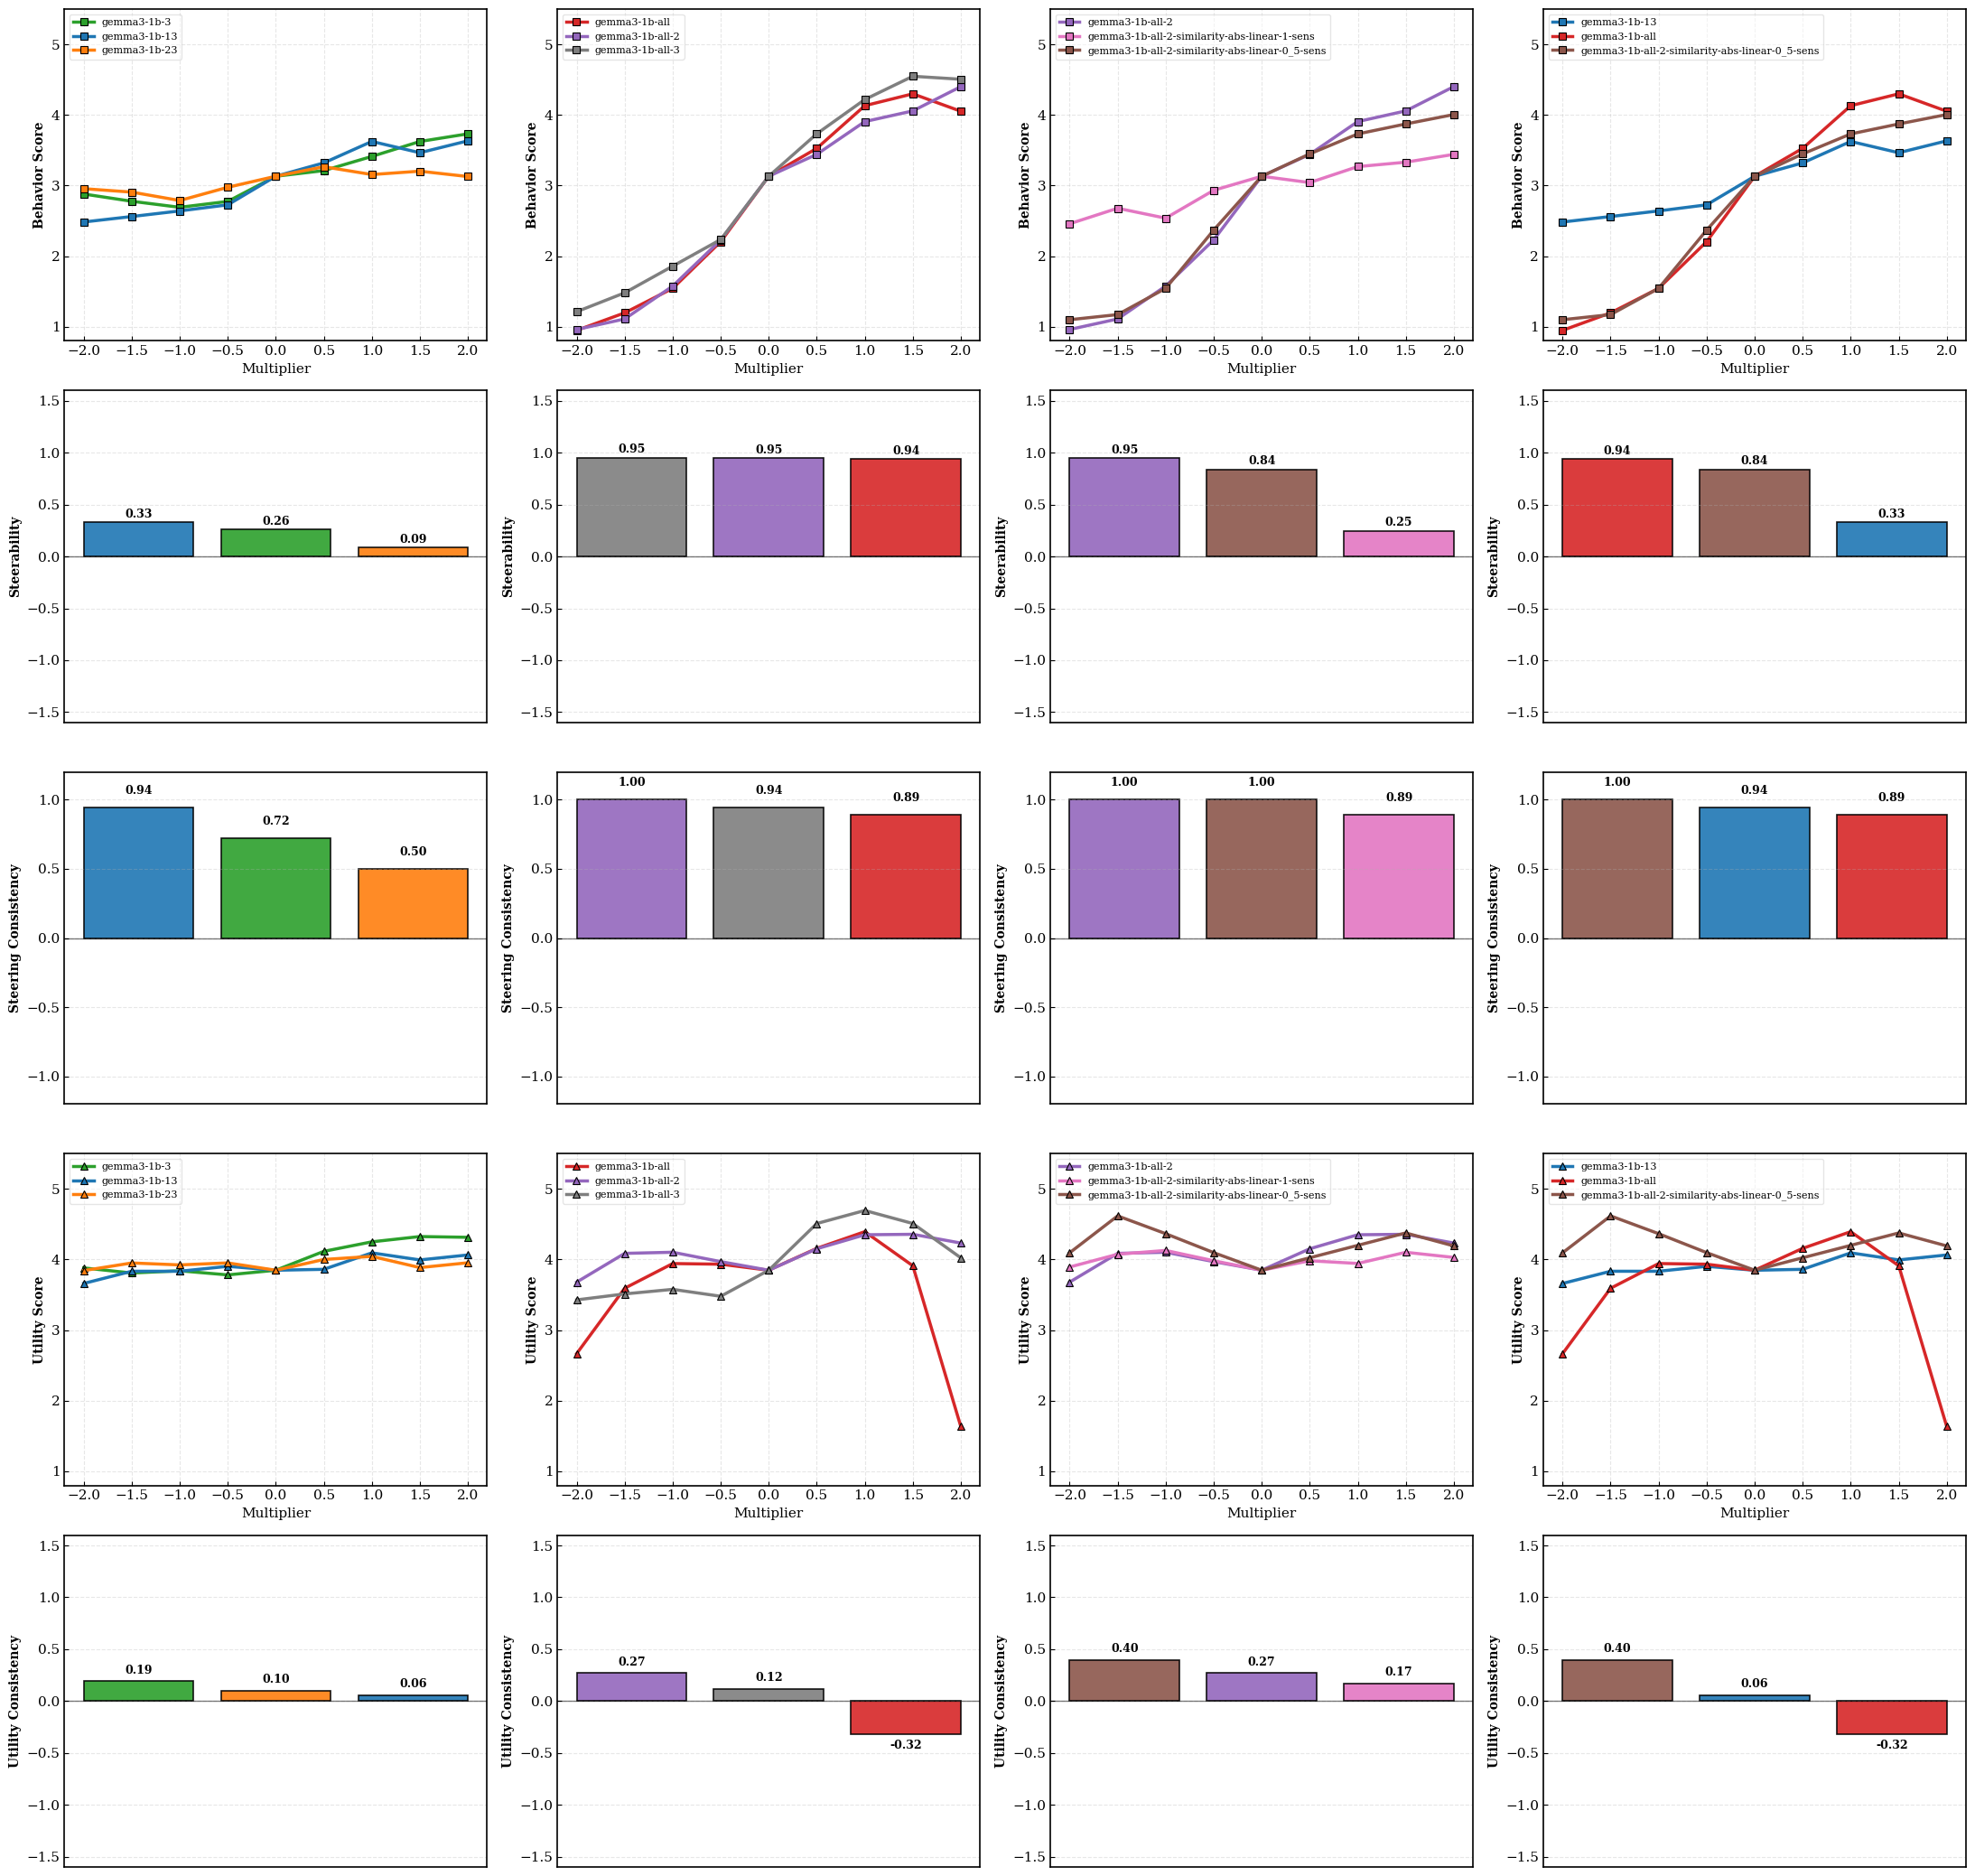

In [5]:
plot_bipo_data(final_data_gemma)

In [6]:
if __name__ == "__main__":
    # Define parameters
    BASE_DIR ="../reasoning/power-seeking/llama" 
    SCORE_COL = "Score" 
    ID_COL = "Question"
    
    FINAL_RESULT_DICT = {
        "Single Layer Ablation": ["llama3-1-8b-6","llama3-1-8b-16","llama3-1-8b-26"],
        "Scale Ablation": ["llama3-1-8b-all","llama3-1-8b-all-2","llama3-1-8b-all-3"],
        "k1 Ablation": ["llama3-1-8b-all-2","llama3-1-8b-all-2-similarity-abs-linear-0_5-sens","llama3-1-8b-all-2-similarity-abs-linear-1-sens"],
        "Final Comparison": ["llama3-1-8b-16","llama3-1-8b-all","llama3-1-8b-all-2-similarity-abs-linear-0_5-sens"],
    }

    
    BASELINES = ["llama3-1-8b-16", "llama3-1-8b-all"]

    # Run function and retrieve results
    final_data_llama, final_mcnemar_results = process_evaluation_data(
        base_dir=BASE_DIR,
        final_result_dict=FINAL_RESULT_DICT,
        score_column=SCORE_COL,
        id_column=ID_COL,
        baseline_subdirs=BASELINES
    )
 

Found 540 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 99 pairs
  - Multiplier -1.5: 97 pairs
  - Multiplier -1.0: 93 pairs
  - Multiplier -0.5: 93 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 20 pairs
  - Multiplier 1.0: 34 pairs
  - Multiplier 1.5: 43 pairs
  - Multiplier 2.0: 59 pairs
------------------------------
Found 340 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 45 pairs
  - Multiplier -1.5: 38 pairs
  - Multiplier -1.0: 24 pairs
  - Multiplier -0.5: 30 pairs
  - Multiplier 0.0: 4 pairs
  - Multiplier 0.5: 47 pairs
  - Multiplier 1.0: 32 pairs
  - Multiplier 1.5: 52 pairs
  - Multiplier 2.0: 68 pairs

=== POPULATED DATA_GEMMA KEYS ===
Single Layer Ablation:
  llama3-1-8b-6 -> Metrics found: ['behavior', 'utility']
  llama3-1-8b-16 -> Metrics found: ['behavior', 'utility']
  llama3-1-8b-26 -> Metrics found: ['behavior', 'utility']
Scale Ablation:
  llama3-1-8b-all -> Metrics found: ['behavior', 'utility']
  llama3-1-8b-all-2 -> Met

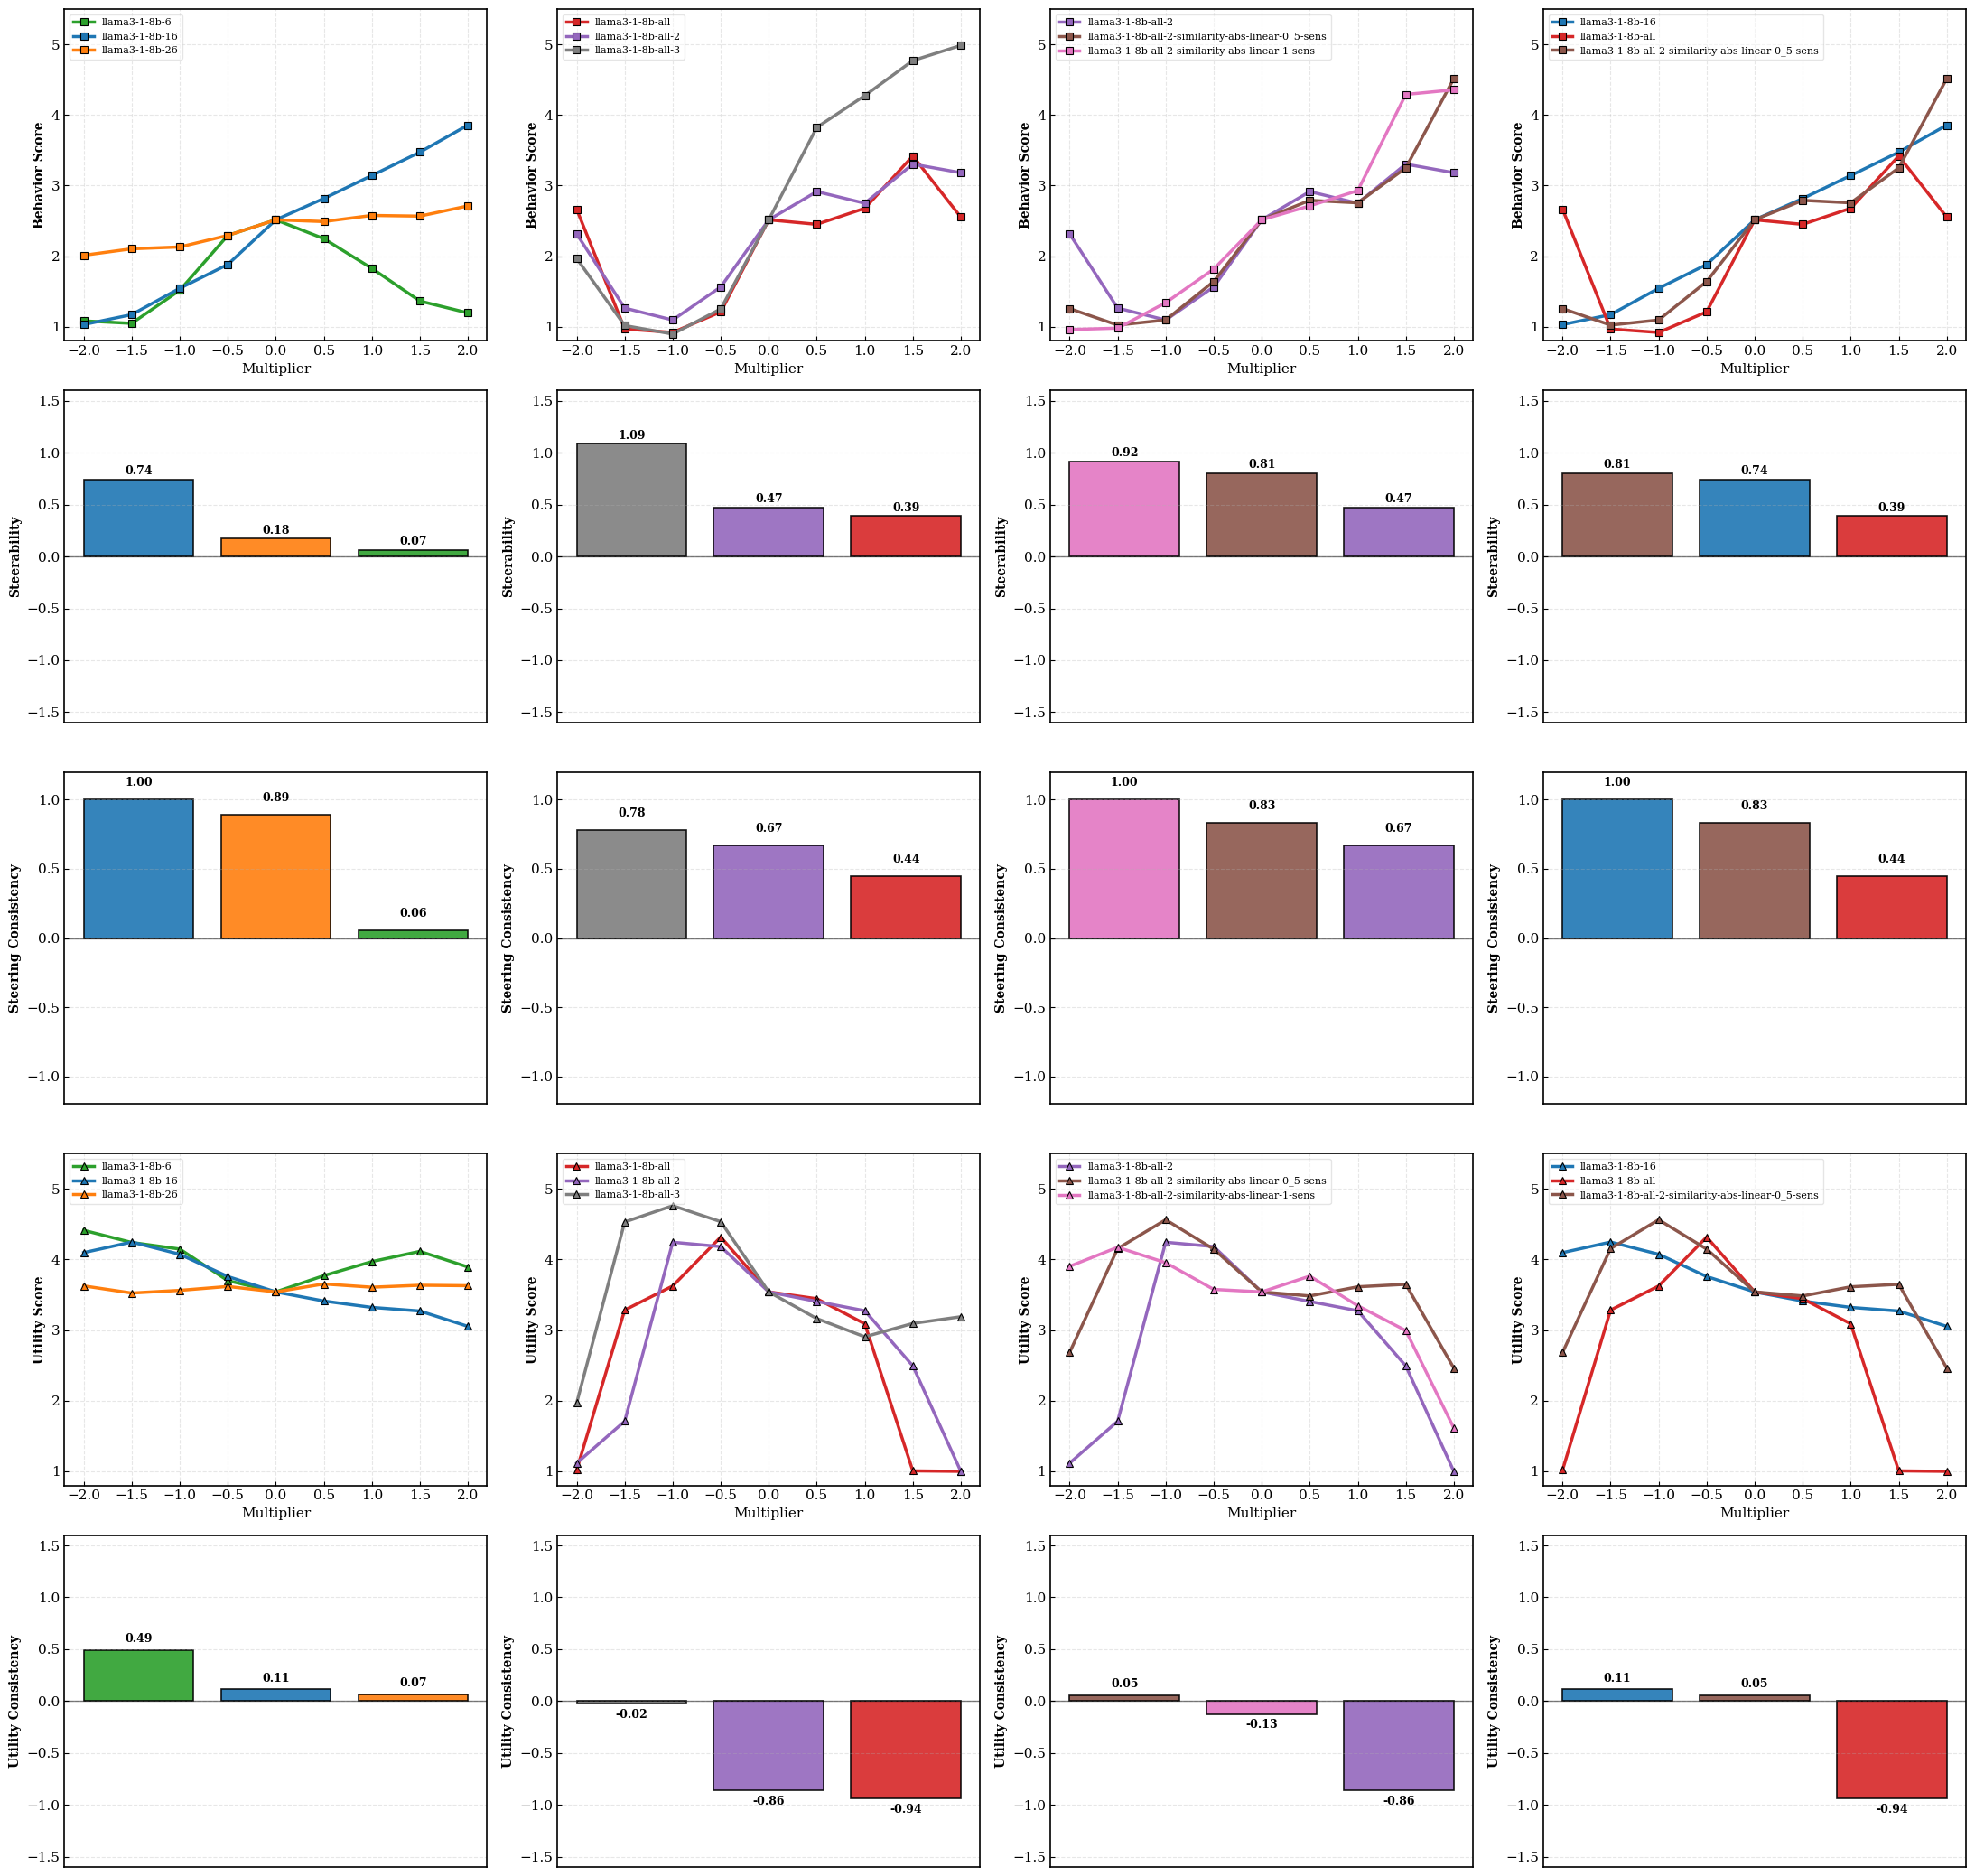

In [7]:
plot_bipo_data(final_data_llama)

In [8]:
if __name__ == "__main__":
    # Define parameters
    BASE_DIR ="../reasoning/power-seeking/mistral" 
    SCORE_COL = "Score" 
    ID_COL = "Question"
    
    FINAL_RESULT_DICT = {
        "Single Layer Ablation": ["mistral-7b-6","mistral-7b-16","mistral-7b-26"],
        "Scale Ablation": ["mistral-7b-all","mistral-7b-all-2","mistral-7b-all-3"],
        "k1 Ablation": ["mistral-7b-all-2","mistral-7b-all-2-similarity-abs-linear-0_5","mistral-7b-all-2-similarity-abs-linear-0_5-sens","mistral-7b-all-2-similarity-abs-linear-1-sens"],
        "Multi Layer Ablation": ["mistral-7b-6","mistral-7b-all","mistral-7b-all-2-similarity-abs-linear-0_5-sens"],
    }

    
    BASELINES = ["mistral-7b-6", "mistral-7b-all"]

    # Run function and retrieve results
    final_data_mistral, final_mcnemar_results = process_evaluation_data(
        base_dir=BASE_DIR,
        final_result_dict=FINAL_RESULT_DICT,
        score_column=SCORE_COL,
        id_column=ID_COL,
        baseline_subdirs=BASELINES
    )
 

Found 599 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 107 pairs
  - Multiplier -1.5: 114 pairs
  - Multiplier -1.0: 115 pairs
  - Multiplier -0.5: 116 pairs
  - Multiplier 0.0: 2 pairs
  - Multiplier 0.5: 37 pairs
  - Multiplier 1.0: 47 pairs
  - Multiplier 1.5: 31 pairs
  - Multiplier 2.0: 30 pairs
------------------------------
Found 164 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 14 pairs
  - Multiplier -1.5: 9 pairs
  - Multiplier -1.0: 15 pairs
  - Multiplier -0.5: 15 pairs
  - Multiplier 0.0: 4 pairs
  - Multiplier 0.5: 29 pairs
  - Multiplier 1.0: 24 pairs
  - Multiplier 1.5: 33 pairs
  - Multiplier 2.0: 21 pairs

=== POPULATED DATA_GEMMA KEYS ===
Single Layer Ablation:
  mistral-7b-6 -> Metrics found: ['behavior', 'utility']
  mistral-7b-16 -> Metrics found: ['behavior', 'utility']
  mistral-7b-26 -> Metrics found: ['behavior', 'utility']
Scale Ablation:
  mistral-7b-all -> Metrics found: ['behavior', 'utility']
  mistral-7b-all-2 -> Metri

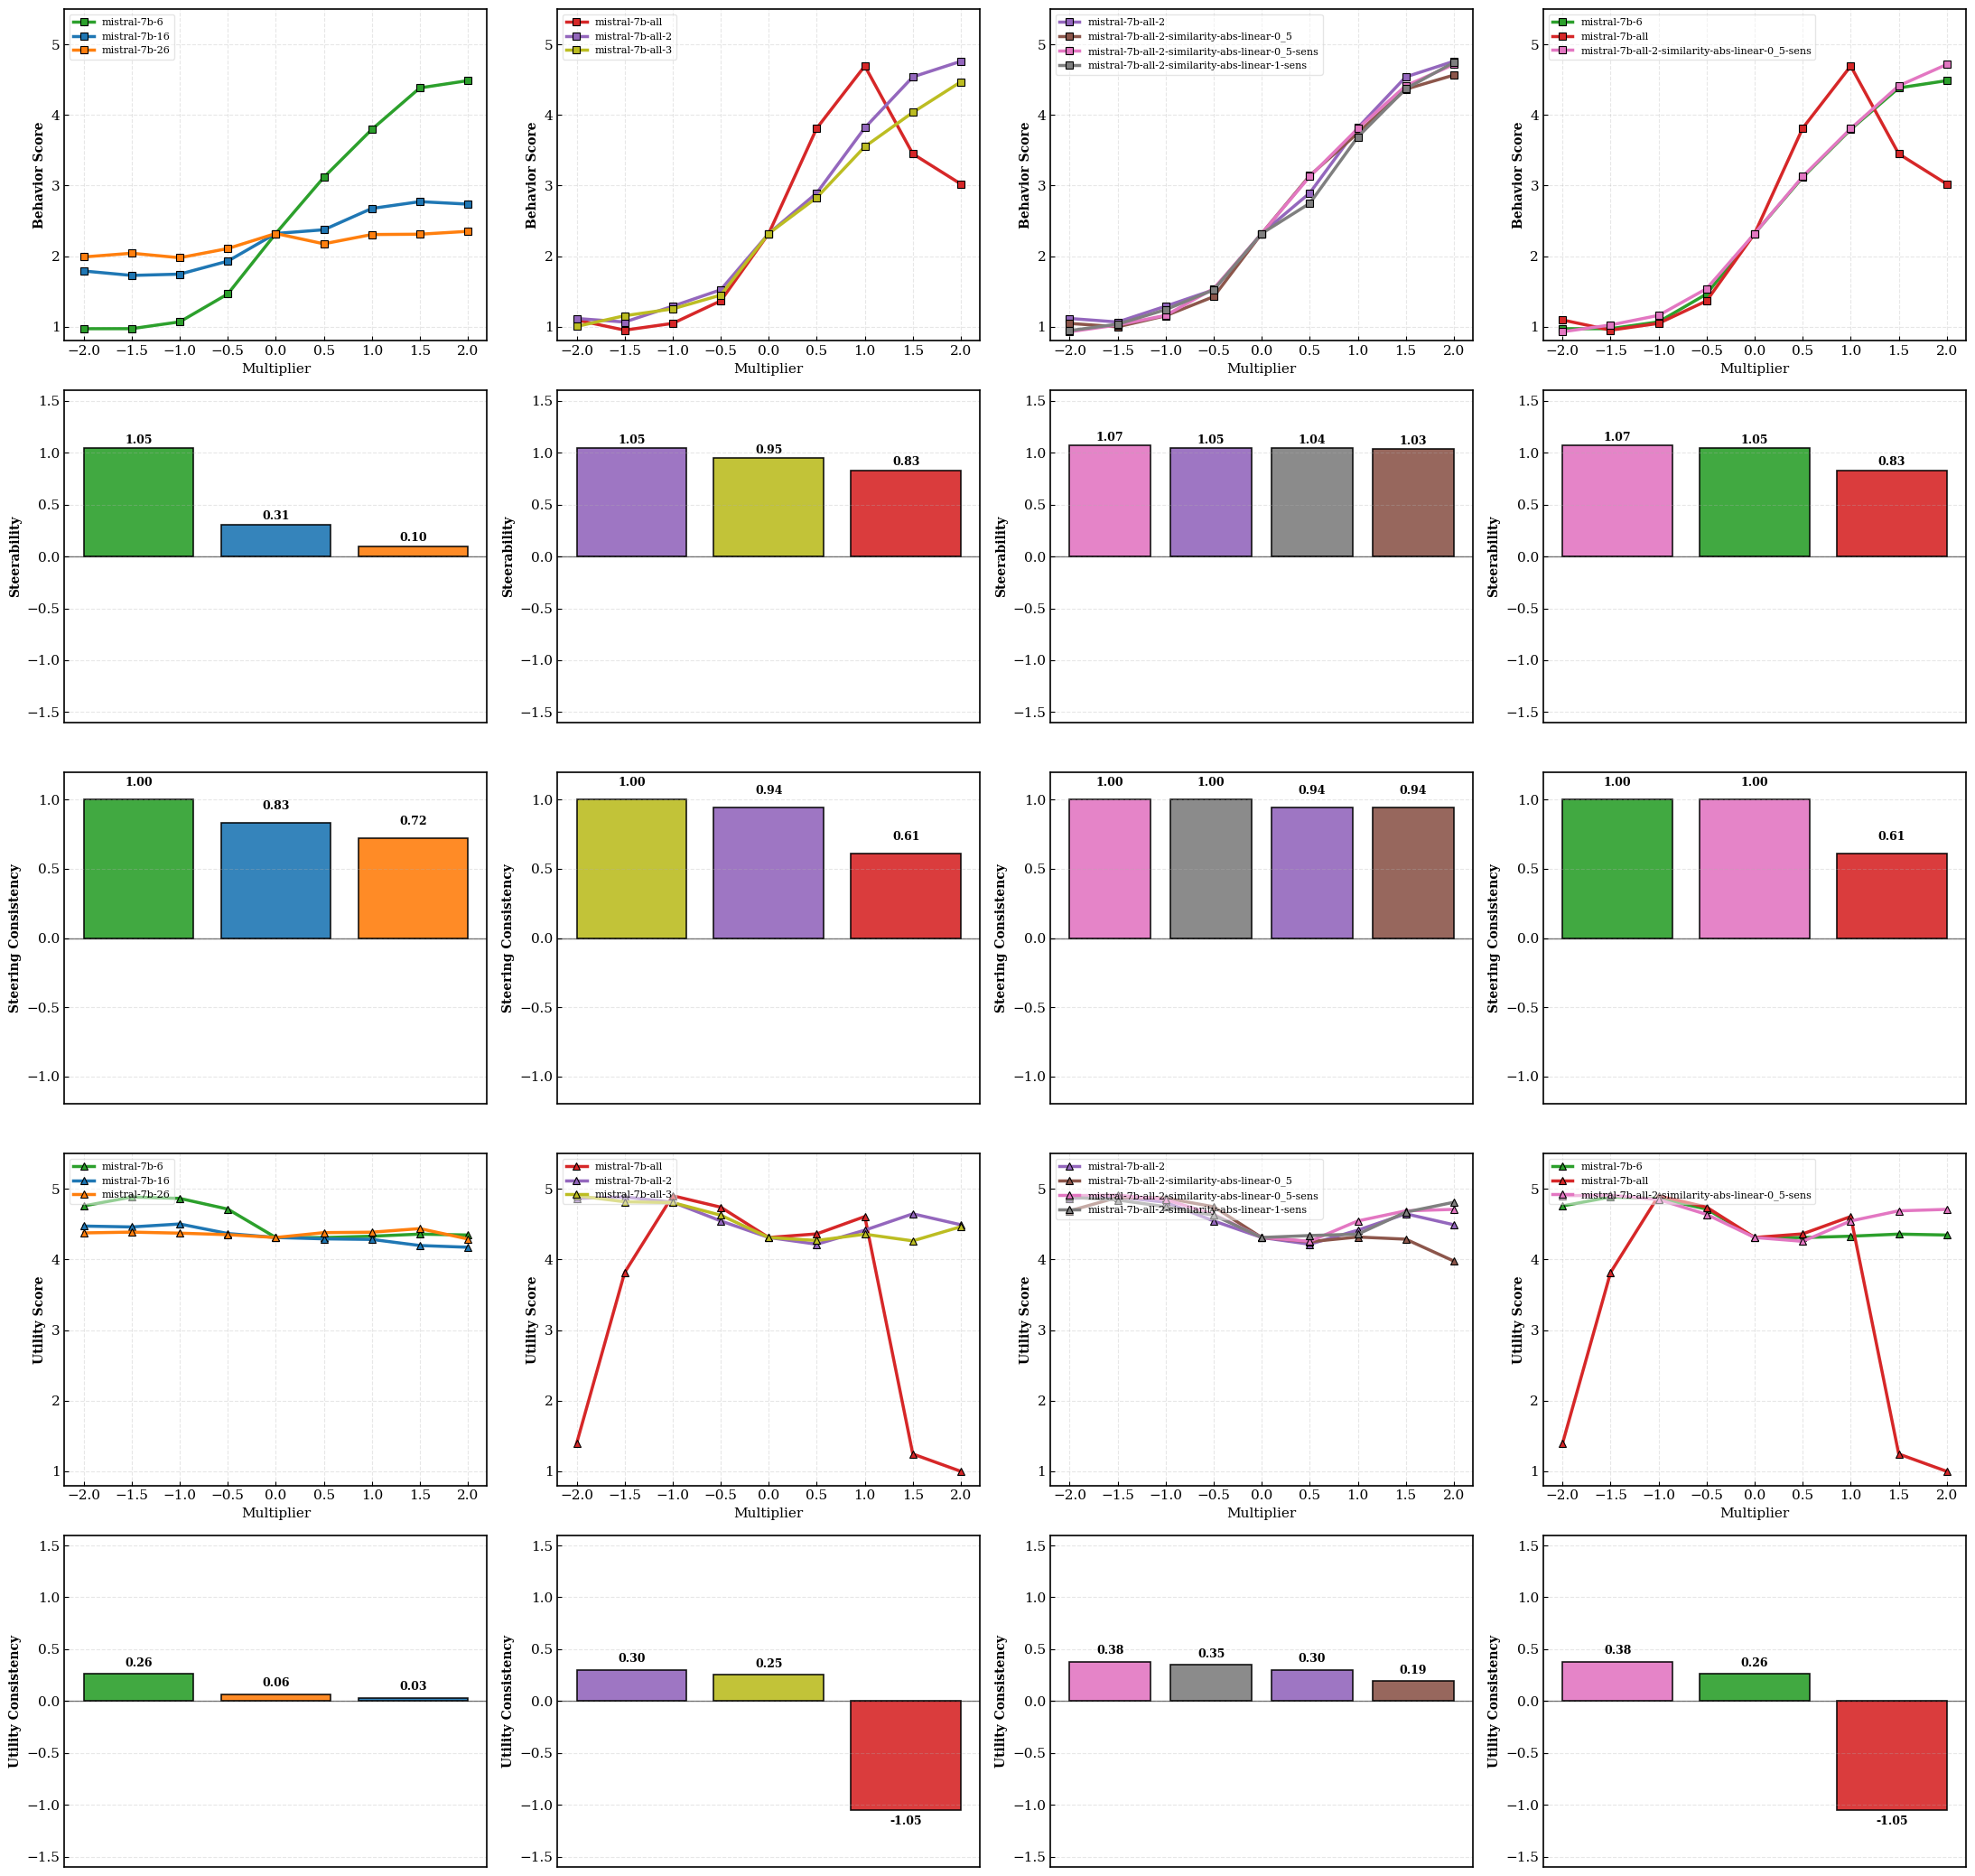

In [9]:
plot_bipo_data(final_data_mistral)